![image.png](https://i.imgur.com/a3uAqnb.png)

# **Build a Dataset Class for Horse Breeds**

https://www.kaggle.com/datasets/olgabelitskaya/horse-breeds

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("olgabelitskaya/horse-breeds")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'horse-breeds' dataset.
Path to dataset files: /kaggle/input/horse-breeds


#### Optional: You can explore more datasets types like TensorDataset, StackDataset here: [Link](https://pytorch.org/docs/stable/data.html#torch.utils.data.TensorDataset)

### Dataset Class

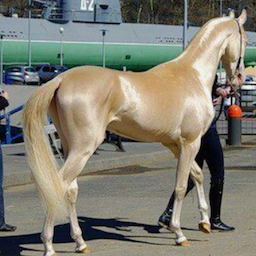

In [2]:
### *📌 Loading Images Using PIL (Pillow)*
### Pillow (`PIL`) is a common Python library for handling images.
from PIL import Image
import os

# Load an image
image_path = os.path.join(path,"01_001.png")
image = Image.open(image_path)

# Display the image
image

### Transforms

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, datasets, models
from torch.utils.data import DataLoader, random_split, Dataset
import matplotlib.pyplot as plt
import numpy as np


transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [4]:
import os
from PIL import Image

class HorseDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform

        self.image_files = [f for f in os.listdir(root_dir) if f.endswith('.png')]
        self.labels = [f.split('_')[0] for f in self.image_files]
        self.classes = sorted(list(set(self.labels)))
        self.class_to_idx = {cls: i for i, cls in enumerate(self.classes)}

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        img_path = os.path.join(self.root_dir, img_name)
        image = Image.open(img_path).convert("RGB")

        label_str = img_name.split('_')[0]
        label = self.class_to_idx[label_str]

        if self.transform:
            image = self.transform(image)

        return image, label

### Create dataset object

In [5]:
dataset = HorseDataset(root_dir=path, transform=transform)

print("Dataset size:", len(dataset))
print("Classes:", dataset.classes)

Dataset size: 670
Classes: ['01', '02', '03', '04', '05', '06', '07']


### Split the data into train and test set

In [6]:
from torch.utils.data import random_split

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

#### Check dataset size


In [7]:
print("Train dataset size: ", len(train_dataset))
print("Test dataset size: ", len(val_dataset))

Train dataset size:  536
Test dataset size:  134


### Create Dataloader objects

In [8]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

### Check the dataset shape


In [9]:
images, labels = next(iter(train_loader))

print("Batch image shape:", images.shape)
print("Batch labels shape:", labels.shape)

Batch image shape: torch.Size([32, 3, 224, 224])
Batch labels shape: torch.Size([32])


#### Display some images

# **Build a classifier model using pretrained model**

**Hint: you can use the pretrained EfficientNet-B0 model.**

### Load pretrained model and modify the classifier based on the given dataset

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18(pretrained=True)

num_classes = len(dataset.classes)

model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 169MB/s]


### Training loop

In [11]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [12]:
def train(model, loader):
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / len(loader), correct / total

### Validation Loop

In [13]:
def validate(model, loader):
    model.eval()
    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return running_loss / len(loader), correct / total

### Running Training

In [15]:
epochs = 10

train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(epochs):
    train_loss, train_acc = train(model, train_loader)
    val_loss, val_acc = validate(model, val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}/{epochs}")
    print(f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")

Epoch 1/10
Train Loss: 0.5237, Acc: 0.8284
Val   Loss: 1.3640, Acc: 0.5821
Epoch 2/10
Train Loss: 0.3947, Acc: 0.8657
Val   Loss: 1.9012, Acc: 0.5821
Epoch 3/10
Train Loss: 0.3813, Acc: 0.8769
Val   Loss: 3.7352, Acc: 0.6045
Epoch 4/10
Train Loss: 0.2588, Acc: 0.9142
Val   Loss: 1.0510, Acc: 0.7388
Epoch 5/10
Train Loss: 0.1555, Acc: 0.9571
Val   Loss: 0.7357, Acc: 0.7687
Epoch 6/10
Train Loss: 0.0903, Acc: 0.9701
Val   Loss: 1.1218, Acc: 0.7463
Epoch 7/10
Train Loss: 0.1124, Acc: 0.9701
Val   Loss: 1.0123, Acc: 0.7910
Epoch 8/10
Train Loss: 0.0506, Acc: 0.9907
Val   Loss: 0.8766, Acc: 0.7985
Epoch 9/10
Train Loss: 0.0655, Acc: 0.9757
Val   Loss: 1.5487, Acc: 0.7463
Epoch 10/10
Train Loss: 0.0548, Acc: 0.9795
Val   Loss: 1.5784, Acc: 0.7164


 ### Plot loss and accuracy for training and validation

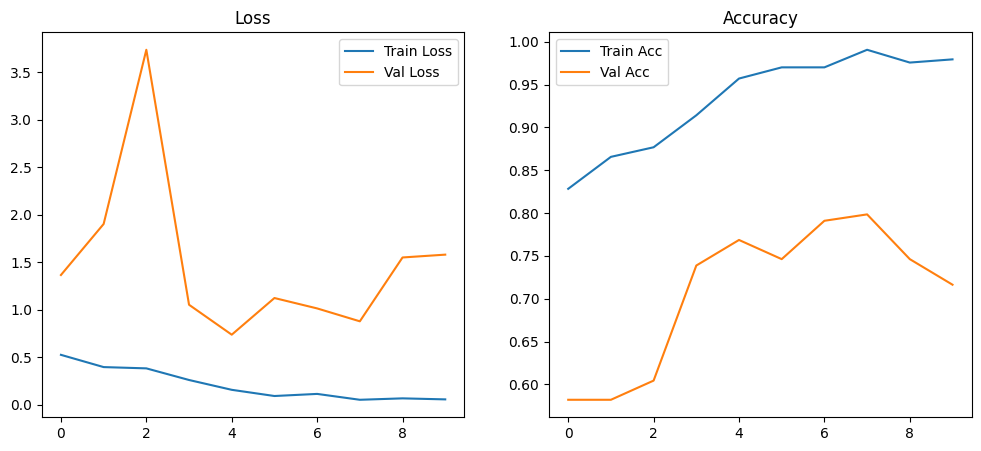

In [16]:
plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.legend()
plt.title("Loss")

# Accuracy
plt.subplot(1,2,2)
plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Val Acc')
plt.legend()
plt.title("Accuracy")

plt.show()

### Display sample of predictions

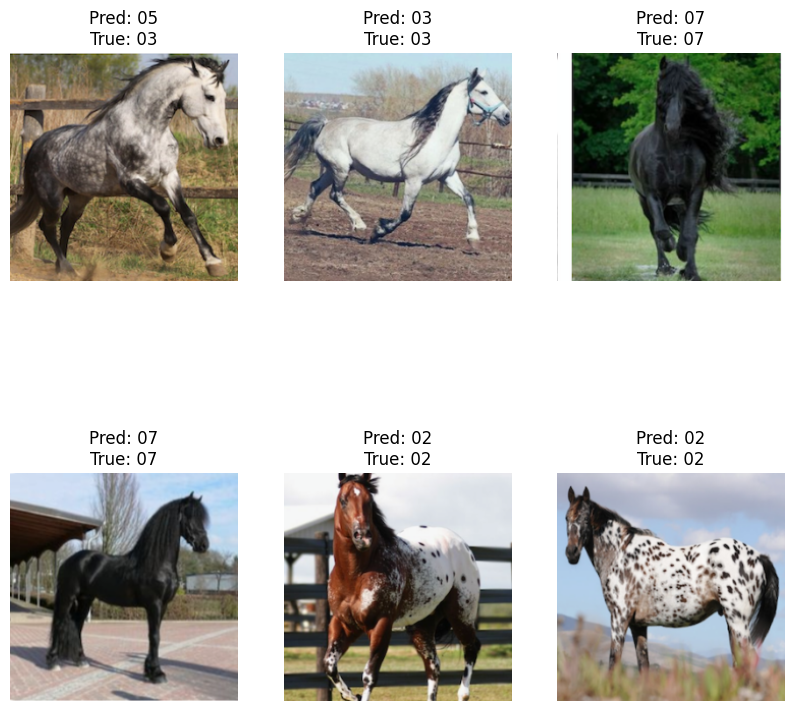

In [17]:
def imshow(img):
    img = img.numpy().transpose((1,2,0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    img = np.clip(img, 0, 1)
    plt.imshow(img)

model.eval()
images, labels = next(iter(val_loader))
images, labels = images.to(device), labels.to(device)

outputs = model(images)
_, preds = torch.max(outputs, 1)

plt.figure(figsize=(10,10))

for i in range(6):
    plt.subplot(2,3,i+1)
    imshow(images[i].cpu())
    plt.title(f"Pred: {dataset.classes[preds[i]]}\nTrue: {dataset.classes[labels[i]]}")
    plt.axis('off')

plt.show()